# Marketing Funnel & Conversion Performance Analysis
## Objective 
Analysis marketing funnel data to identify conversion drop-offs, customer behaviour, and opportunities to improve conversion rates.

## Tools Used
- Python
- Pandas
- Matplotlib
- seaborn 
- Jupyter Notebook

## Dataset Information
This project uses two datsets:
- 2019-Oct.csv
- 2019-Nov.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
oct_df = pd.read_csv("2019-Oct.csv")
oct_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [4]:
nov_df = pd.read_csv("2019-Nov.csv")
nov_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


## Combine Data

## Data Cleaning and Inspection

In [13]:
oct_df = pd.read_csv("2019-Oct.csv", nrows=500000)
nov_df = pd.read_csv("2019-Nov.csv", nrows=500000)

In [14]:
df = pd.concat([oct_df, nov_df], ignore_index=True)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


## Data cleaning and Inspection

In [15]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   event_time     1000000 non-null  str    
 1   event_type     1000000 non-null  str    
 2   product_id     1000000 non-null  int64  
 3   category_id    1000000 non-null  int64  
 4   category_code  679189 non-null   str    
 5   brand          853358 non-null   str    
 6   price          1000000 non-null  float64
 7   user_id        1000000 non-null  int64  
 8   user_session   1000000 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 68.7 MB


event_time            0
event_type            0
product_id            0
category_id           0
category_code    320811
brand            146642
price                 0
user_id               0
user_session          0
dtype: int64

## Funnel Stage Analysis

In [16]:
funnel = df['event_type'].value_counts()
print(funnel)

event_type
view        964475
purchase     19353
cart         16172
Name: count, dtype: int64


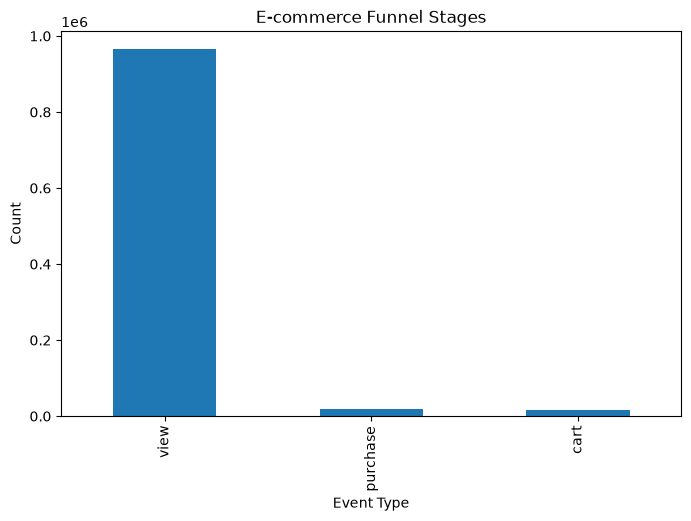

In [17]:
funnel.plot(kind='bar', figsize=(8,5))
plt.title("E-commerce Funnel Stages")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

## Top product Categories

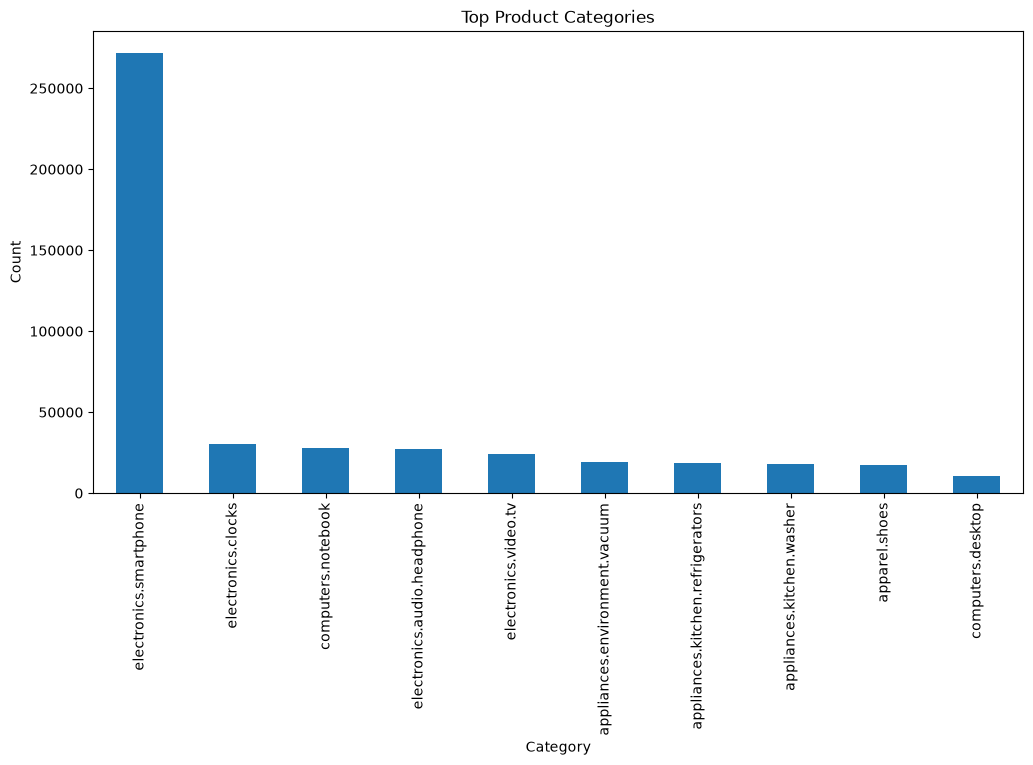

In [19]:
top_categories = df['category_code'].value_counts().head(10)

top_categories.plot(kind='bar', figsize=(12,6))
plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

## Top Brands Analysis

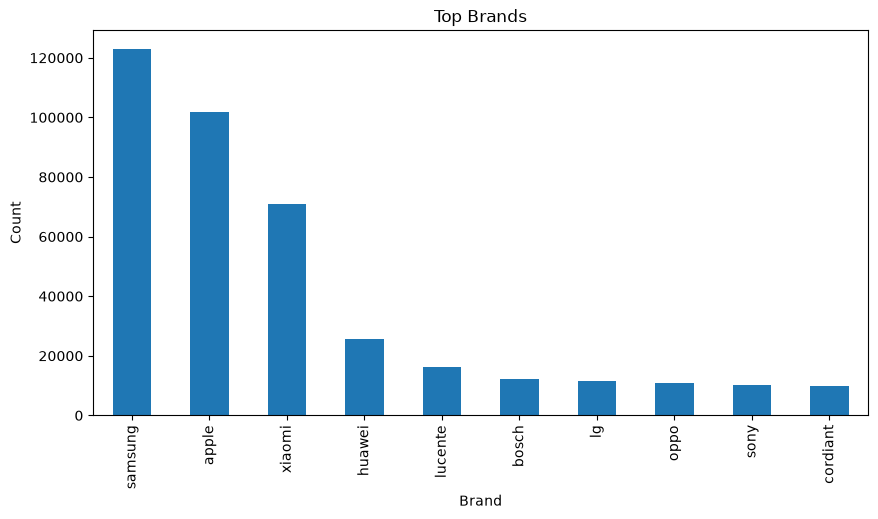

In [20]:
top_brands = df['brand'].value_counts().head(10)

top_brands.plot(kind='bar', figsize=(10,5))
plt.title("Top Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

In [22]:
print(df['event_time'].head())
print(df['day'].head())

0   2019-10-01 00:00:00+00:00
1   2019-10-01 00:00:00+00:00
2   2019-10-01 00:00:01+00:00
3   2019-10-01 00:00:01+00:00
4   2019-10-01 00:00:04+00:00
Name: event_time, dtype: datetime64[us, UTC]
0    1
1    1
2    1
3    1
4    1
Name: day, dtype: int32


## Conversion Rate Bar Chart

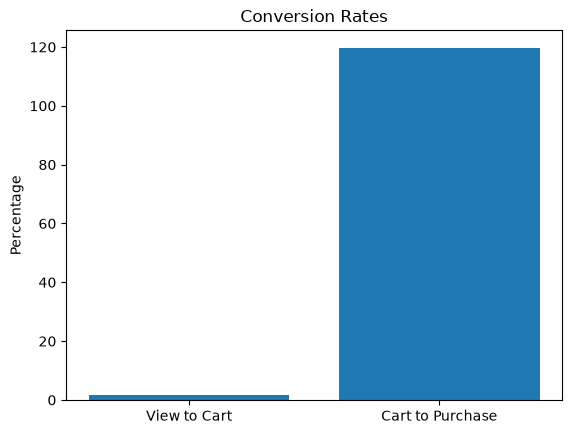

In [26]:
funnel_counts = df['event_type'].value_counts()

conversion_rates = [
    (funnel_counts['cart'] / funnel_counts['view']) * 100,
    (funnel_counts['purchase'] / funnel_counts['cart']) * 100
]

stages = ['View to Cart', 'Cart to Purchase']

plt.bar(stages, conversion_rates)
plt.title("Conversion Rates")
plt.ylabel("Percentage")
plt.show()

## Top categories pie chart

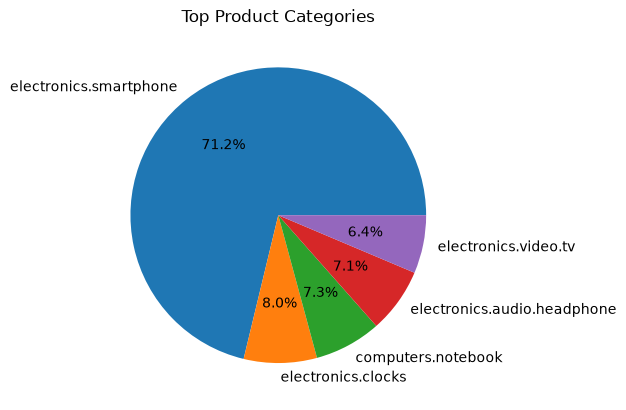

In [27]:
top_categories = df['category_code'].value_counts().head(5)

top_categories.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top Product Categories")
plt.ylabel("")
plt.show()

## Conclusion

- Most users drop off at the View stage.
- Smartphones are the most popular category.
- Samsung is the top brand.
- User activity peaked around the middle of the month.
- Improvements in product pages and checkout flow can increase conversions.